In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Exercício

1. Gere uma amostra de tamanho $M$ de uma exponencial através do método de inversão visto em sala. Compare com uma exponencial gerada pelo numpy via histogramas. Comparem também com a densidade real da exponencial $f(x) = \lambda e^{-\lambda x}$ (isto é, seu histograma normalizado tem que ficar igual essa curva).

In [2]:
lamb = 2
M = 100_000
exp_np = np.random.exponential(1/lamb, size = M)
uniformes = np.random.uniform(size=M)
exp_inversa = -np.log(uniformes)/lamb

$$F(t) = 1 - \exp(-\lambda t)$$
$$F^{-1}(u) = -\frac{1}{\lambda} \ln(1 - u)$$

In [3]:
x = np.linspace(0,3,M)
y = lamb*np.exp(-lamb*x)

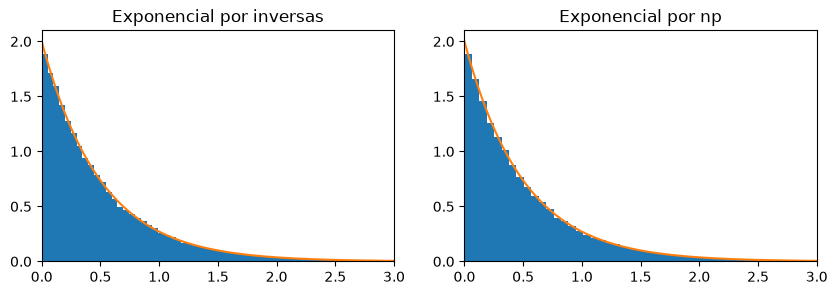

In [4]:
fig, ax = plt.subplots(1,2, figsize=(10,3), sharex=True)
plt.xlim(0,3)
ax[0].hist(exp_inversa, density = True, bins = 100)
ax[0].plot(x,y)
ax[0].set_title('Exponencial por inversas')
ax[1].hist(exp_np, density=True, bins= 100)
ax[1].set_title('Exponencial por np')
ax[1].plot(x,y)
plt.show()

2. Agora considere $T_n = X_n / n$ onde $X_n$ é uma Geométrica com parâmetro $\lambda/n$. Mostre que quando $n$ é grande, isso se aproxima de uma exponencial.

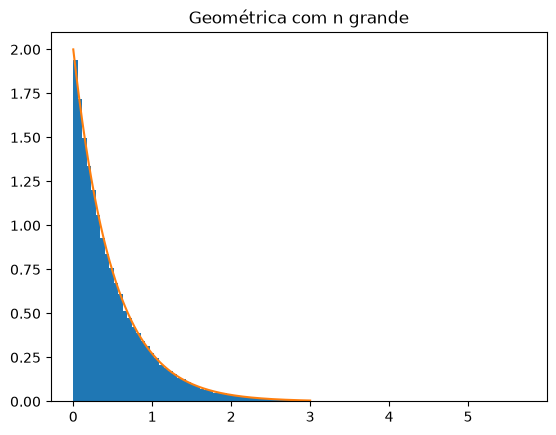

In [5]:
n = 1000
u = np.random.uniform(size=M)
Xn = np.ceil(np.log(u)/np.log(1-(lamb/n)))
Tn = Xn/n
plt.hist(Tn, density=True, bins=100)
plt.plot(x,y)
plt.title('Geométrica com n grande')
plt.show()

3. Considere agora $X_1, X_2, \ldots$ variáveis aleatórias i.i.d. com distribuição Exponencial de parâmetro $\lambda$. Vá somando essas variáveis até que a soma ultrapasse $1$ e conte quantas delas foram somadas antes de ultrapassar $1$. Repita esse procedimento $M$ vezes e mostre empiricamente que essa quantidade segue aproximadamente uma Poisson de parâmetro $\lambda$. Compare o histograma obtido com uma Poisson gerada pelo numpy e com a função de probabilidade real da Poisson.

In [6]:
uniformes = np.random.uniform(size=(M,50))
exponenciais = -np.log(uniformes)/lamb
soma_acumulada = exponenciais.cumsum(axis=1)

mascara = soma_acumulada < 1
exponenciais_filtradas = np.where(mascara, exponenciais, 0)
contagem = np.where(exponenciais_filtradas != 0, 1, 0)

In [7]:
amostra_poisson = np.sum(contagem,axis=1)

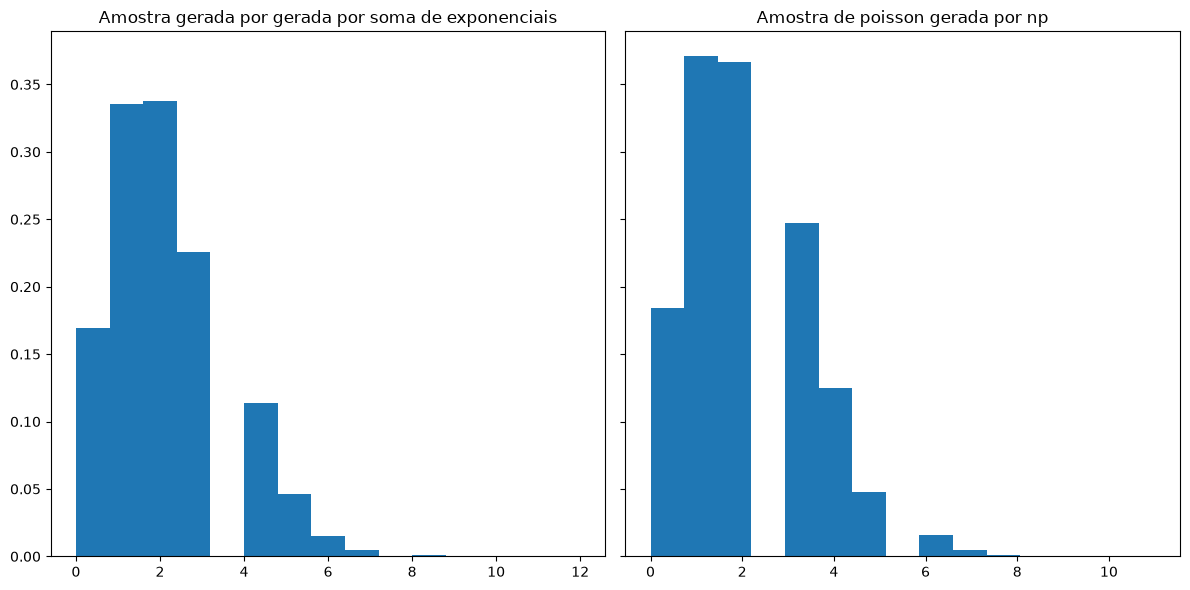

In [9]:
fig, ax = plt.subplots(1,2, figsize=(12,6), sharey=True)
ax[0].hist(amostra_poisson, density=True, bins=15)
ax[0].set_title('Amostra gerada por gerada por soma de exponenciais')

ax[1].hist(np.random.poisson(lamb,size=M), density=True, bins = 15)
ax[1].set_title('Amostra de poisson gerada por np')
plt.tight_layout()
plt.show()